made by Kataoka @2024/07/15

Predicting low reynolds number cylinder flow.  
Governing equation is Steady Navier Stokes Equation.

# Library

In [1]:
# Standard Library
import os
import sys
import copy
import glob
import time
import random
import pickle
from decimal import Decimal

In [2]:
# External Library
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Settings

In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)

In [4]:
# Set random seed
seed_ = 2434
random.seed(seed_)
torch.manual_seed(seed_)
np.random.seed(seed_)

In [5]:
# Select device
# device = torch.device("cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Function

In [6]:
def sample_from_square_except_circle(
    num_sampling, 
    x_range,
    y_range, 
    circle_center,
    circle_radius
):

    points_array = np.empty(shape=(0,2))

    for i in range(2*num_sampling):

        candidate = np.random.rand(1,2)
        #print(candidate)
        candidate[0][0] = (x_range[1]-x_range[0]) * candidate[0][0] + x_range[0]
        candidate[0][1] = (y_range[1]-y_range[0]) * candidate[0][1] + y_range[0]

        temp = candidate - np.array(circle_center).reshape(1, 2)
        dist2center = np.sqrt(temp[0][0]**2+temp[0][1]**2)

        if dist2center<circle_radius:
            continue
        else:
            points_array = np.concatenate([points_array, candidate], axis=0)


        if len(points_array)==num_sampling:
            break

    if len(points_array)>num_sampling or len(points_array)<num_sampling:
        print("failed to sample points.")
        sys.exit()

    return points_array

In [7]:
def sample_from_circle_edge(num_sampling, circle_center, circle_radius):

    points_array = np.random.rand(num_sampling, 1)

    x_array = circle_radius * np.cos(2*np.pi * points_array)
    y_array = circle_radius * np.sin(2*np.pi * points_array)

    output_array = np.concatenate([x_array.reshape(-1,1), y_array.reshape(-1,1)], axis=1) + circle_center

    return output_array

In [8]:
def sample_from_line(num_sampling, x_range):
    
    points_array = np.random.rand(num_sampling, 1)

    size_array = np.concatenate([np.full((num_sampling, 1), x_range[1]-x_range[0])], axis=1)
    min_array = np.concatenate([np.full((num_sampling, 1), x_range[0])], axis=1)

    return points_array * size_array + min_array

In [9]:
def sample_from_line_2d(num_sampling, x, y):
    
    if type(x)==list:
        x_point = sample_from_line(num_sampling, x)
        y_point = np.full(x_point.shape, y)
        
        return np.concatenate([x_point, y_point], axis=1)
    
    elif type(y)==list:
        y_point = sample_from_line(num_sampling, y)
        x_point = np.full(y_point.shape, x)
        
        return np.concatenate([x_point, y_point], axis=1)

In [10]:
class DNN(nn.Module):
    
    def __init__(self, input_dim, output_dim, num_hidden_layers, num_neurons_per_layer, activation_function):
        super(DNN, self).__init__()

        self.layers = nn.ModuleList()
        self.activation_function = activation_function.lower()
        self.function = self._get_activation_function()

        # Model 
        self.layers.append(nn.Linear(input_dim, num_neurons_per_layer))

        for _ in range(num_hidden_layers - 1):
            self.layers.append(nn.Linear(num_neurons_per_layer, num_neurons_per_layer))

        self.layers.append(nn.Linear(num_neurons_per_layer, output_dim))

        # Initialize weights
        self.kaming_function = ["relu"]
        self.xavier_function = ["sigmoid", "tanh"]
        self._initialize_weights()


    def _get_activation_function(self):
        
        if self.activation_function == "relu":
            return torch.nn.functional.relu
        
        elif self.activation_function == "sigmoid":
            return torch.sigmoid
        
        elif self.activation_function == "tanh":
            return torch.tanh
        
        else:
            raise ValueError(f"Unsupported activation function: {self.activation_function}")


    def _initialize_weights(self):
        
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                
                if self.activation_function in self.kaming_function:
                    nn.init.kaiming_normal_(layer.weight, nonlinearity=self.activation_function)
                
                elif self.activation_function in self.xavier_function:
                    nn.init.xavier_normal_(layer.weight)
                
                else:
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='linear')
                    
                nn.init.zeros_(layer.bias)


    def forward(self, x):
        
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self._get_activation_function()(x)

        x = self.layers[-1](x)
        
        return x

In [11]:
class PhysicsInformedNN():
    
    def __init__(self, device, model, dataset, data_loader, Re):
        
        ## initialization
        self.device = device
        self.dnn = model.to(device)
        self.Re = Re
        
        ## Data
        self.dataset = dataset
        self.data_loader = data_loader

        ## Loss History
        self.loss_history = {"initial": [], "boundary": [], "residual": [], "total": []}
        
        ## epoch information
        self.epoch = 0
        
        ## optimizer
        self.optimizer = torch.optim.Adam(self.dnn.parameters(), lr=0.01)
        #self.optimizer = torch.optim.LBFGS(self.dnn.parameters())
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(self.optimizer, gamma=0.95)


    def net_u(self, x, y, t):  
        
        outputs = self.dnn(torch.cat([x, y, t], dim=1).to(self.device))
        u = outputs[:, 0:1]
        v = outputs[:, 1:2]
        p = outputs[:, 2:3]
        
        return u, v, p


    def net_ux(self, x, y, t):  
        
        outputs = self.dnn(torch.cat([x, y, t], dim=1).to(self.device))
        u = outputs[:, 0:1]
        v = outputs[:, 1:2]
        p = outputs[:, 2:3]
        
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), retain_graph=True, create_graph=True)[0]
        
        return u_x, v_x, p_x
    
    
    def net_f(self, x, y, t):

        u, v, p = self.net_u(x, y, t)
        
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), retain_graph=True, create_graph=True)[0]

        v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), retain_graph=True, create_graph=True)[0]
        v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), retain_graph=True, create_graph=True)[0]
        
        p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), retain_graph=True, create_graph=True)[0]
        p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), retain_graph=True, create_graph=True)[0]        
        
        f_x = u_t + u * u_x + v * u_y + p_x - 1/self.Re * (u_xx + u_yy)
        f_y = v_t + u * v_x + v * v_y + p_y - 1/self.Re * (v_xx + v_yy)
        f_continue = u_x + v_y
        
        return f_x, f_y, f_continue
    
    
    def train(self, nIter):
        
        thisEpochId = self.get_id()
        
        for batch in range(len(list(thisEpochId.values()))):

            temp = []
            _, loss_info = self.culc_loss(thisEpochId, batch)

            temp.append(loss_info)

        loss_info_ = [0] * len(temp[0])

        for i in range(len(temp[0])):
            l = [x[0] for x in temp]
            loss_info_[i] = sum(l)/len(l)

        self.loss_history["boundary"].append(loss_info_[0:6])
        self.loss_history["residual"].append(loss_info[6:10])
        self.loss_history["total"].append(loss_info[10])
        
        print("epoch: {:05} | bound: {:.8f}, res: {:.8f}, total: {:.8f}".format(self.epoch, loss_info_[5], loss_info_[9], loss_info_[10]))
        
        if self.visualizer_config:
                self.train_visualization()

        for epoch in range(nIter):
            
            self.dnn.train()
            
            self.epoch += 1
            thisEpochId = self.get_id()
        
            for batch in range(len(list(thisEpochId.values()))):
                
                temp = []
                
                def closure():
                    self.optimizer.zero_grad()

                    loss, _ = self.culc_loss(thisEpochId, batch)
                    loss.backward()

                    return loss

                self.optimizer.step(closure)

                ## calculate the loss again for monitoring
                _, loss_info = self.culc_loss(thisEpochId, batch)
                
                temp.append(loss_info)
                
            loss_info_ = [0] * len(temp[0])

            for i in range(len(temp[0])):
                l = [x[i] for x in temp]
                loss_info_[i] = sum(l)/len(l)
            
            if self.epoch%10==0:
                print("epoch: {:05} | init: {:.8f}, bound: {:.8f}, res: {:.8f}, total: {:.8f}".format(self.epoch, loss_info[2], loss_info_[8], loss_info_[12], loss_info_[13]))
            
            if self.epoch%10==0:
                self.loss_history["initial"].append(loss_info_[0:3])
                self.loss_history["boundary"].append(loss_info_[3:9])
                self.loss_history["residual"].append(loss_info_[9:13])
                self.loss_history["total"].append(loss_info_[13])

            if self.epoch%100==0:
                if self.visualizer_config:
                    self.train_visualization()
                    
            if self.epoch%500==0:
                self.scheduler.step()

        return

                
    def get_id(self):
        
        thisEpochId = {}
            
        for key in self.data_loader.keys():
            thisEpochId[key] = []
            
            for idx, _, _, _  in self.data_loader[key]:
                thisEpochId[key].append(idx)

        return thisEpochId
        
                
    def culc_loss(self, thisEpochId, batch):

        loss_info = []
        
        ## initial loss
        idx_init = thisEpochId["initial"][batch]
        x_init = torch.tensor(self.dataset["initial"].points[idx_init][:, 0:1], requires_grad=True).float().to(self.device)
        y_init = torch.tensor(self.dataset["initial"].points[idx_init][:, 1:2], requires_grad=True).float().to(self.device)
        t_init = torch.tensor(self.dataset["initial"].points[idx_init][:, 2:3], requires_grad=True).float().to(self.device)
        u_init = torch.tensor(self.dataset["initial"].velocity[idx_init][:, 0:1]).float().to(self.device)
        v_init = torch.tensor(self.dataset["initial"].velocity[idx_init][:, 1:2]).float().to(self.device)
        
        u_pred_init, v_pred_init, _ = self.net_u(x_init, y_init, t_init)
        u_init_loss = torch.mean((u_init - u_pred_init) ** 2)
        v_init_loss = torch.mean((v_init - v_pred_init) ** 2)
        
        init_loss = u_init_loss + v_init_loss
        with torch.no_grad():
            loss_info.extend([
                u_init_loss.cpu().numpy().item(), 
                v_init_loss.cpu().numpy().item(), 
                init_loss.cpu().numpy().item()]
                            )
            
        del x_init, y_init, t_init, u_init, v_init, u_pred_init, v_pred_init, init_loss, u_init_loss, v_init_loss
        torch.cuda.empty_cache()
        
        ## boundary loss
        idx_bound = thisEpochId["boundary"][batch]
        x_bound = torch.tensor(self.dataset["boundary"].points[idx_bound][:, 0:1], requires_grad=True).float().to(self.device)
        y_bound = torch.tensor(self.dataset["boundary"].points[idx_bound][:, 1:2], requires_grad=True).float().to(self.device)
        t_bound = torch.tensor(self.dataset["boundary"].points[idx_bound][:, 2:3], requires_grad=True).float().to(self.device)
        u_bound = torch.tensor(self.dataset["boundary"].velocity[idx_bound][:, 0:1]).float().to(self.device)
        v_bound = torch.tensor(self.dataset["boundary"].velocity[idx_bound][:, 1:2]).float().to(self.device)
        cdt = torch.tensor(self.dataset["boundary"].condition[idx_bound]).float().to(self.device)

        ## Dirichlet Boundary
        u_pred_bound, v_pred_bound, p_pred_bound = self.net_u(x_bound, y_bound, t_bound)
        dirichlet_idx_u = torch.where(cdt%2==1, cdt, torch.zeros_like(cdt))
        dirichlet_idx_p = torch.where(cdt==3, cdt, torch.zeros_like(cdt))
        
        u_dirichlet_bound_loss = torch.mean(dirichlet_idx_u * (u_bound - u_pred_bound) ** 2)
        v_dirichlet_bound_loss = torch.mean(dirichlet_idx_u * (v_bound - v_pred_bound) ** 2)
        p_dirichlet_bound_loss = torch.mean(dirichlet_idx_p * (p_pred_bound) ** 2)

        ## Neumann Boundary
        ux_pred_bound, vx_pred_bound, _ = self.net_ux(x_bound, y_bound, t_bound)
        neumann_idx = torch.where(cdt==2, cdt, torch.zeros_like(cdt))

        u_neumann_bound_loss = torch.mean(neumann_idx * (u_bound - ux_pred_bound) ** 2)
        v_neumann_bound_loss = torch.mean(neumann_idx * (v_bound - vx_pred_bound) ** 2)

        bound_loss =  u_dirichlet_bound_loss + v_dirichlet_bound_loss + p_dirichlet_bound_loss + u_neumann_bound_loss + v_neumann_bound_loss
        with torch.no_grad():
            loss_info.extend([
                u_neumann_bound_loss.cpu().numpy().item(), 
                v_neumann_bound_loss.cpu().numpy().item(), 
                p_dirichlet_bound_loss.cpu().numpy().item(), 
                u_dirichlet_bound_loss.cpu().numpy().item(), 
                v_dirichlet_bound_loss.cpu().numpy().item(), 
                bound_loss.cpu().numpy().item()]
                            )
                
        del x_bound, y_bound, t_bound, u_bound, v_bound, u_pred_bound, cdt, v_pred_bound, neumann_idx, ux_pred_bound, vx_pred_bound, dirichlet_idx_u, dirichlet_idx_p
        del u_dirichlet_bound_loss, v_dirichlet_bound_loss, p_dirichlet_bound_loss, u_neumann_bound_loss, v_neumann_bound_loss
        torch.cuda.empty_cache()
        
        ## residual loss
        idx_res = thisEpochId["residual"][batch]
        x_res = np.concatenate([self.dataset["residual"].points[idx_res][:, 0:1], self.dataset["boundary"].points[idx_bound][:, 0:1], self.dataset["initial"].points[idx_init][:, 0:1]], axis=0)
        x_res = torch.tensor(x_res, requires_grad=True).float().to(self.device)
        y_res = np.concatenate([self.dataset["residual"].points[idx_res][:, 1:2], self.dataset["boundary"].points[idx_bound][:, 1:2], self.dataset["initial"].points[idx_init][:, 1:2]], axis=0)
        y_res = torch.tensor(y_res, requires_grad=True).float().to(self.device)
        t_res = np.concatenate([self.dataset["residual"].points[idx_res][:, 2:3], self.dataset["boundary"].points[idx_bound][:, 2:3], self.dataset["initial"].points[idx_init][:, 2:3]], axis=0)
        t_res = torch.tensor(t_res, requires_grad=True).float().to(self.device)

        f_pred_x, f_pred_y, f_pred_continue = self.net_f(x_res, y_res, t_res) 

        fx_loss = torch.mean(f_pred_x ** 2)
        fy_loss = torch.mean(f_pred_y ** 2)
        fc_loss = torch.mean(f_pred_continue ** 2)
        
        res_loss = fx_loss + fy_loss + fc_loss
        with torch.no_grad():
            loss_info.extend([
                fx_loss.cpu().numpy().item(), 
                fy_loss.cpu().numpy().item(), 
                fc_loss.cpu().numpy().item(), 
                res_loss.cpu().numpy().item()])
        
        loss = bound_loss + res_loss
        with torch.no_grad():
            loss_info.append(loss.cpu().numpy().item())
        
        return loss, loss_info
    

    def set_train_visualizer(self, output_dir, x_range, y_range, t_range, resolution, cylinder_center, cylinder_radius, min_max, label):

        self.visualizer_config = {
            "output_dir": output_dir,
            "x_range": x_range,
            "y_range": y_range,
            "t_range": t_range,
            "resolution": resolution,
            "cylinder_center": cylinder_center,
            "cylinder_radius": cylinder_radius,
            "min_max": min_max,
            "label": label
        }
                
        
    def train_visualization(self):

        output_dir = self.visualizer_config["output_dir"]
        x_range = self.visualizer_config["x_range"]
        y_range = self.visualizer_config["y_range"]
        t_range = self.visualizer_config["t_range"]
        resolution = self.visualizer_config["resolution"]
        cylinder_center = self.visualizer_config["cylinder_center"]
        cylinder_radius = self.visualizer_config["cylinder_radius"]
        min_max = self.visualizer_config["min_max"]
        label = self.visualizer_config["label"]

        path2loss = os.path.join(output_dir, "loss")
        path2predict = os.path.join(output_dir, "predict")

        if not os.path.exists(path2loss):
            os.makedirs(path2loss)
        if not os.path.exists(path2predict):
            os.makedirs(path2predict)

        fig = plt.figure(figsize = (8, 6))
        ax = fig.add_subplot(111)
        
        ax.set_yscale("log")

        ax.plot(self.loss_history["total"])
        fig.savefig(os.path.join(path2loss, "output_{:05}.png".format(self.epoch)), dpi=500)
        
        plt.close(fig)
                
        x = np.linspace(x_range[0], x_range[1], resolution[0])
        y = np.linspace(y_range[0], y_range[1], resolution[1])
        xx, yy = np.meshgrid(x, y)
        
        temp = np.concatenate([xx.reshape((-1,1)),yy.reshape((-1,1))], axis=1)
        
        t_list = [[t_range[0], "s"], [t_range[1]/2, "m"], [t_range[1], "f"]]

        for t in t_list:
    
            temp_ = np.concatenate([temp, np.full((len(temp),1), t[0])], axis=1)
            u, v, p = self.predict(temp_)

            if label=="velocity_x":
                mmm = u
            elif label=="velocity_y":
                mmm = v
            elif label=="pressure":
                mmm = p
            elif label=="velocity_mag":
                mmm = np.sqrt(u**2 + v**2)

            for i in range(len(mmm)):
                if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
                    mmm[i] = np.nan
            mmm = np.flipud(mmm.reshape(resolution[1], resolution[0]))

            figure = plot_Scalar2D(xx, yy, mmm, vmin=min_max[0], vmax=min_max[1], label=label)
            figure.savefig(os.path.join(path2predict, "output_{:05}_{}.png".format(self.epoch, t[1])), dpi=500)

            plt.close(figure)
        
            
    def predict(self, X):
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(self.device)
        y = torch.tensor(X[:, 1:2], requires_grad=True).float().to(self.device)
        t = torch.tensor(X[:, 2:3], requires_grad=True).float().to(self.device)
        
        self.dnn.eval()
        u, v, p = self.net_u(x, y, t)
        u = u.detach().cpu().numpy()
        v = v.detach().cpu().numpy()
        p = p.detach().cpu().numpy()
        
        return u, v, p

In [12]:
def plot_Scalar2D(
    X, Y, img, split_x=6, split_y=4, vmin=-1, vmax=1, label="velocity"
):
    """
    docstring
    """
    
    fig = plt.figure(figsize = (8, 2))
    ax = fig.add_subplot(111)
    
    Q = ax.imshow(img, cmap="coolwarm", vmin=vmin, vmax=vmax)
    
    X = X.reshape(-1)
    Y = Y.reshape(-1)
    
    height = img.shape[0]
    width = img.shape[1]
    
    ax.set_xlabel("x", size = 14)
    ax.set_ylabel("y", size = 14)
    ax.set_xticks(np.linspace(0, width-1, split_x+1))
    ax.set_yticks(np.linspace(0, height-1, split_y+1))
    ax.set_xticklabels(np.round(np.linspace(min(X), max(X), split_x+1),3))
    ax.set_yticklabels(np.round(np.linspace(min(Y), max(Y), split_y+1),3)[::-1])

    ax.set_aspect("equal")
    
    fig.colorbar(Q, label=label)
    
    #plt.show()
    
    return fig

In [13]:
class PointsDataset(Dataset):
    
    def __init__(self, points, velocity, condition):
        self.points = points
        self.velocity = velocity
        self.condition = condition

    def __len__(self):
        return len(self.points)

    def __getitem__(self, idx):
        points_item = self.points[idx]
        velocity_item = self.velocity[idx]
        condition_item = self.condition[idx]
        return idx, points_item, velocity_item, condition_item

# Main

In [14]:
## Representative Value

rep_length = 0.1
rep_velocity = 0.05
rep_viscosity = 0.001

Re = (rep_length * rep_velocity) / rep_viscosity
print(Re)

5.000000000000001


In [15]:
#Region

x_range = [0.0, 24.0]
y_range = [0.0, 4.0]
cylinder_center = [2.0, 2.0]
cylinder_radius = 0.5

t_range = [0.0, 10.0]
t_split = 1

In [16]:
# Number of points

num_sampling_Xedge = 3000
num_sampling_Yedge = 14000
num_sampling_cylinder = 2000
num_sampling_region = 120000

num_sampling_Xedge_init = 300
num_sampling_Yedge_init = 1600
num_sampling_cylinder_init = 200
num_sampling_region_init = 10000

num_initial = num_sampling_region_init
num_boundary = t_split*(2*num_sampling_Xedge + 2*num_sampling_Yedge + num_sampling_cylinder + 2*num_sampling_Xedge_init + 2*num_sampling_Yedge_init + num_sampling_cylinder_init)
num_residual = t_split * num_sampling_region

In [17]:
print(num_initial)
print(num_boundary)
print(num_residual)

10000
40000
120000


In [18]:
def inlet_distribution_u(y, y_max, u_max):
    
    u = (4*u_max*y*(y_max-y))/(y_max**2)
    v = np.full((u.shape), 0)
    
    return np.concatenate([u, v], axis=1)

In [19]:
## condition
## 
## 1: on the velocity dirichlet boundary (res, bound_d)
## 2: on the velocity neumann boundary (res, bound_n)
## 3: on the pressure zero dirichlet boundary (res, bound_d)

In [20]:
temp_p = sample_from_square_except_circle(num_sampling_region_init, x_range, y_range,  cylinder_center, cylinder_radius)
temp_v = np.full((temp_p.shape), 0)
temp_p_ = np.full((num_sampling_region_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_initial = temp_p
velocity_initial = temp_v

In [21]:
temp_p = sample_from_line_2d(num_sampling_Xedge_init, x_range[0], y_range)
temp_v = inlet_distribution_u(temp_p[:, 1:2], y_range[1], u_max=1.5)
temp_c = np.full((len(temp_p), 1), 1)
temp_p_ = np.full((num_sampling_Xedge_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_boundary = temp_p
velocity_boundary = temp_v
condition_boundary = temp_c

temp_p = sample_from_line_2d(num_sampling_Xedge_init, x_range[1], y_range)
temp_v = np.full((temp_p.shape), 0)
temp_c = np.full((len(temp_p), 1), 2)
temp_p_ = np.full((num_sampling_Xedge_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

temp_p = sample_from_line_2d(num_sampling_Yedge_init, x_range, y_range[0])
temp_v = np.full((temp_p.shape), 0)
temp_c = np.full((len(temp_p), 1), 1)
temp_p_ = np.full((num_sampling_Yedge_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

temp_p = sample_from_line_2d(num_sampling_Yedge_init, x_range, y_range[1])
temp_v = np.full((temp_p.shape), 0)
temp_c = np.full((len(temp_p), 1), 1)
temp_p_ = np.full((num_sampling_Yedge_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

temp_p = sample_from_circle_edge(num_sampling_cylinder_init, cylinder_center, cylinder_radius)
temp_v = np.full((temp_p.shape), 0)
temp_c = np.full((len(temp_p), 1), 1)
temp_p_ = np.full((num_sampling_cylinder_init, 1), 0)
temp_p = np.concatenate([temp_p, temp_p_], axis=1)
points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

for i in range(t_split):
    
    t_min = i*t_range[1]/t_split
    t_max = (i+1)*t_range[1]/t_split
    t_delta = t_max - t_min
    
    temp_p = sample_from_line_2d(num_sampling_Xedge, x_range[0], y_range)
    temp_v = inlet_distribution_u(temp_p[:, 1:2], y_range[1], u_max=1.5)
    temp_p_ = t_delta * np.random.rand(num_sampling_Xedge, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    temp_c = np.full((len(temp_p), 1), 1)
    points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
    velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
    condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

    temp_p = sample_from_line_2d(num_sampling_Xedge, x_range[1], y_range)
    temp_v = np.full((temp_p.shape), 0)
    temp_p_ = t_delta * np.random.rand(num_sampling_Xedge, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    temp_c = np.full((len(temp_p), 1), 2)
    points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
    velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
    condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

    temp_p = sample_from_line_2d(num_sampling_Yedge, x_range, y_range[0])
    temp_v = np.full((temp_p.shape), 0)
    temp_p_ = t_delta * np.random.rand(num_sampling_Yedge, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    temp_c = np.full((len(temp_p), 1), 1)
    points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
    velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
    condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

    temp_p = sample_from_line_2d(num_sampling_Yedge, x_range, y_range[1])
    temp_v = np.full((temp_p.shape), 0)
    temp_p_ = t_delta * np.random.rand(num_sampling_Yedge, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    temp_c = np.full((len(temp_p), 1), 1)
    points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
    velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
    condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

    temp_p = sample_from_circle_edge(num_sampling_cylinder, cylinder_center, cylinder_radius)
    temp_v = np.full((temp_p.shape), 0)
    temp_p_ = t_delta * np.random.rand(num_sampling_cylinder, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    temp_c = np.full((len(temp_p), 1), 1)
    points_boundary = np.concatenate([points_boundary, temp_p], axis=0)
    velocity_boundary = np.concatenate([velocity_boundary, temp_v], axis=0)
    condition_boundary = np.concatenate([condition_boundary, temp_c], axis=0)

In [22]:
for i in range(t_split):
    
    t_min = i*t_range[1]/t_split
    t_max = (i+1)*t_range[1]/t_split
    t_delta = t_max - t_min
    
    temp_p = sample_from_square_except_circle(num_sampling_region, x_range, y_range,  cylinder_center, cylinder_radius)
    temp_p_ = t_delta * np.random.rand(num_sampling_region, 1) + t_min
    temp_p = np.concatenate([temp_p, temp_p_], axis=1)
    
    if i==0:
        points_residual = temp_p
    else:
        points_residual = np.concatenate([points_residual, temp_p_], axis=0)

In [23]:
points_residual.shape

(120000, 3)

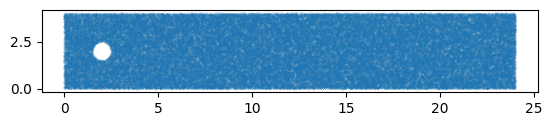

In [24]:
plt.axes().set_aspect("equal")
plt.scatter(points_residual.T[0], points_residual.T[1], s=0.01)

In [25]:
## Batch size
batch_i = 2048
batch_r = 32768
batch_b = 8192

In [26]:
residual_dataset = PointsDataset(points_residual, np.full((points_residual.shape), 0), np.full((points_residual.shape), 0))
boundary_dataset = PointsDataset(points_boundary, velocity_boundary, condition_boundary)
initial_dataset = PointsDataset(points_initial, velocity_initial, np.full((points_initial.shape), 0))
dataset = dict(residual=residual_dataset, boundary=boundary_dataset, initial=initial_dataset)

data_loader_r = DataLoader(residual_dataset, batch_size=batch_r, shuffle=True)
data_loader_b = DataLoader(boundary_dataset, batch_size=batch_b, shuffle=True)
data_loader_i = DataLoader(initial_dataset, batch_size=batch_i, shuffle=True)
data_loader = dict(residual=data_loader_r, boundary=data_loader_b, initial=data_loader_i)

In [27]:
input_dim = 3
output_dim = 3
num_hidden_layers = 5
num_neurons_per_layer = 64
activation_function = "tanh"

In [28]:
dnn = DNN(input_dim, output_dim, num_hidden_layers, num_neurons_per_layer, activation_function)
pinns = PhysicsInformedNN(device, dnn, dataset, data_loader, Re)
pinns.set_train_visualizer(
                          output_dir="/mnt/MachineLearning/flow_field_prediction/PINNs/case_cylinder_retry/lowReynolds_unsteady_NSequation", 
                            x_range=x_range, 
                            y_range=y_range, 
                            t_range=t_range,
                            resolution=[2400, 400], 
                            cylinder_center=cylinder_center,
                            cylinder_radius=cylinder_radius,
                            min_max = [0, 1.4], 
                            label="velocity_mag"
                            )

In [ ]:
pinns.train(50000)

epoch: 00000 | bound: 0.67562938, res: 0.67562938, total: 0.67562938
epoch: 00010 | init: 0.02258885, bound: 0.05285836, res: 0.00844147, total: 0.06129983
epoch: 00020 | init: 0.01144709, bound: 0.03072362, res: 0.00916916, total: 0.03989278
epoch: 00030 | init: 0.01416653, bound: 0.01873076, res: 0.01029071, total: 0.02902147
epoch: 00040 | init: 0.01616944, bound: 0.01421460, res: 0.01002715, total: 0.02424175
epoch: 00050 | init: 0.02002420, bound: 0.01351416, res: 0.00942101, total: 0.02293517
epoch: 00060 | init: 0.02359394, bound: 0.01045972, res: 0.00969378, total: 0.02015350
epoch: 00070 | init: 0.02379020, bound: 0.00959796, res: 0.00981608, total: 0.01941405
epoch: 00080 | init: 0.02570598, bound: 0.00875070, res: 0.00967087, total: 0.01842156
epoch: 00090 | init: 0.03270751, bound: 0.01315582, res: 0.01032647, total: 0.02348229
epoch: 00100 | init: 0.02429175, bound: 0.00802790, res: 0.00994496, total: 0.01797286
epoch: 00110 | init: 0.02386441, bound: 0.00894018, res: 0.00

In [ ]:
plt.plot([x[5] for x in pinns.loss_history["boundary"]])

In [ ]:
x = np.linspace(x_range[0], x_range[1], 2400)
y = np.linspace(y_range[0], y_range[1], 400)
xx, yy = np.meshgrid(x, y)

temp = np.concatenate([xx.reshape((-1,1)),yy.reshape((-1,1))], axis=1)
u, v, p = pinns.predict(temp)

mmm = p
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm, vmin=-2.25, vmax=2.0, label="velocity_x")

mmm = u
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm, vmin=-1.8, vmax=0.8, label="velocity_y")
#figure.savefig(os.path.join(path2predict, "output_{:05}.png".format(self.epoch)), dpi=500)

mmm = v
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm, vmin=-1.0, vmax=8.0, label="prssure")

mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm, vmin=0, vmax=2.4, label="velocity_mag")

In [ ]:
x = np.linspace(x_range[0], x_range[1], 2400)
y = np.linspace(y_range[0], y_range[1], 400)
xx, yy = np.meshgrid(x, y)

temp = np.concatenate([xx.reshape((-1,1)),yy.reshape((-1,1))], axis=1)
u, v, p = pinns.predict(temp)

mmm = p
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm)#, vmin=-2.25, vmax=2.0, label="velocity_x")

mmm = u
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm)#, vmin=-1.8, vmax=0.8, label="velocity_y")
#figure.savefig(os.path.join(path2predict, "output_{:05}.png".format(self.epoch)), dpi=500)

mmm = v
#mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm)#, vmin=-1.0, vmax=8.0, label="prssure")

mmm = np.sqrt(u**2 + v**2)

for i in range(len(mmm)):
    if  np.linalg.norm(temp[i]-np.array(cylinder_center)) < cylinder_radius:
        mmm[i] = np.nan
mmm = np.flipud(mmm.reshape(400, 2400))

figure = plot_Scalar2D(xx, yy, mmm)#, vmin=0, vmax=2.4, label="velocity_mag")

In [ ]:
x = np.linspace(x_range[0], x_range[1], 2400)
y = np.linspace(y_range[0], y_range[1], 400)
xx, yy = np.meshgrid(x, y)

temp = np.concatenate([xx.reshape((-1,1)),yy.reshape((-1,1))], axis=1)
u, v, p = pinns.predict(temp)
mmm = np.sqrt(u**2 + v**2)

u.max(), u.min(), v.max(), v.min(), p.max(), p.min(), mmm.max(), mmm.min()

In [ ]:
with open("PINNs.pkl", "wb") as f:
    pickle.dump(pinns, f)

In [ ]:
type(u)

In [ ]:
np.save("velocity_x.npy", u)
np.save("velocity_y.npy", v)
np.save("velocity_mag.npy", mmm)
np.save("pressure.npy", p)